In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('ratings_.csv', header=None, names=["user_id", "prod_id", "rating", "timestamp"])

In [3]:
df.head()

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [4]:
df.shape

(7824482, 4)

# Clean and Shrink the Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   user_id    object 
 1   prod_id    object 
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


In [6]:
df.isnull().sum()

user_id      0
prod_id      0
rating       0
timestamp    0
dtype: int64

In [7]:
df[df['rating'] > 0]

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
...,...,...,...,...
7824477,A2YZI3C9MOHC0L,BT008UKTMW,5.0,1396569600
7824478,A322MDK0M89RHN,BT008UKTMW,5.0,1313366400
7824479,A1MH90R0ADMIK0,BT008UKTMW,4.0,1404172800
7824480,A10M2KEFPEQDHN,BT008UKTMW,4.0,1297555200


In [8]:
df[df.duplicated()]

,user_id,prod_id,rating,timestamp


In [9]:
df.drop(['timestamp'],axis=1,inplace=True)

In [10]:
valid_users = df['user_id'].value_counts()
valid_users = valid_users[valid_users >= 50].index

In [11]:
df_users = df[df['user_id'].isin(valid_users)]

valid_products = df_users['prod_id'].value_counts()
valid_products = valid_products[valid_products >= 5].index

In [12]:
df_final = df_users[df_users['prod_id'].isin(valid_products)]

In [13]:
df_final

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0
...,...,...,...
7824423,A34BZM6S9L7QI4,B00LGQ6HL8,5.0
7824424,A1G650TTTHEAL5,B00LGQ6HL8,5.0
7824425,A25C2M3QF9G7OQ,B00LGQ6HL8,5.0
7824426,A1E1LEVQ9VQNK,B00LGQ6HL8,5.0


In [14]:
df_final['user_id'].value_counts()

user_id
ADLVFFE4VBT8      295
A3OXHLG6DIBRW8    230
A1ODOGXEYECQQ8    217
A36K2N527TXXJN    212
A25C2M3QF9G7OQ    203
                 ... 
A16CVJUQOB6GIB      2
A2BGZ52M908MJY      2
A3DL29NLZ7SXXG      1
AP2NZAALUQKF5       1
A3MV1KKHX51FYT      1
Name: count, Length: 1540, dtype: int64

In [15]:
df_final['prod_id'].value_counts()

prod_id
B0088CJT4U    206
B003ES5ZUU    184
B000N99BBC    167
B007WTAJTO    164
B00829TIEK    149
             ... 
B00368CDH6      5
B0036AZA6A      5
B0036E8V08      5
B0036QL1JY      5
B00LGQ6HL8      5
Name: count, Length: 5689, dtype: int64

# EDA

In [16]:
df_final.describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

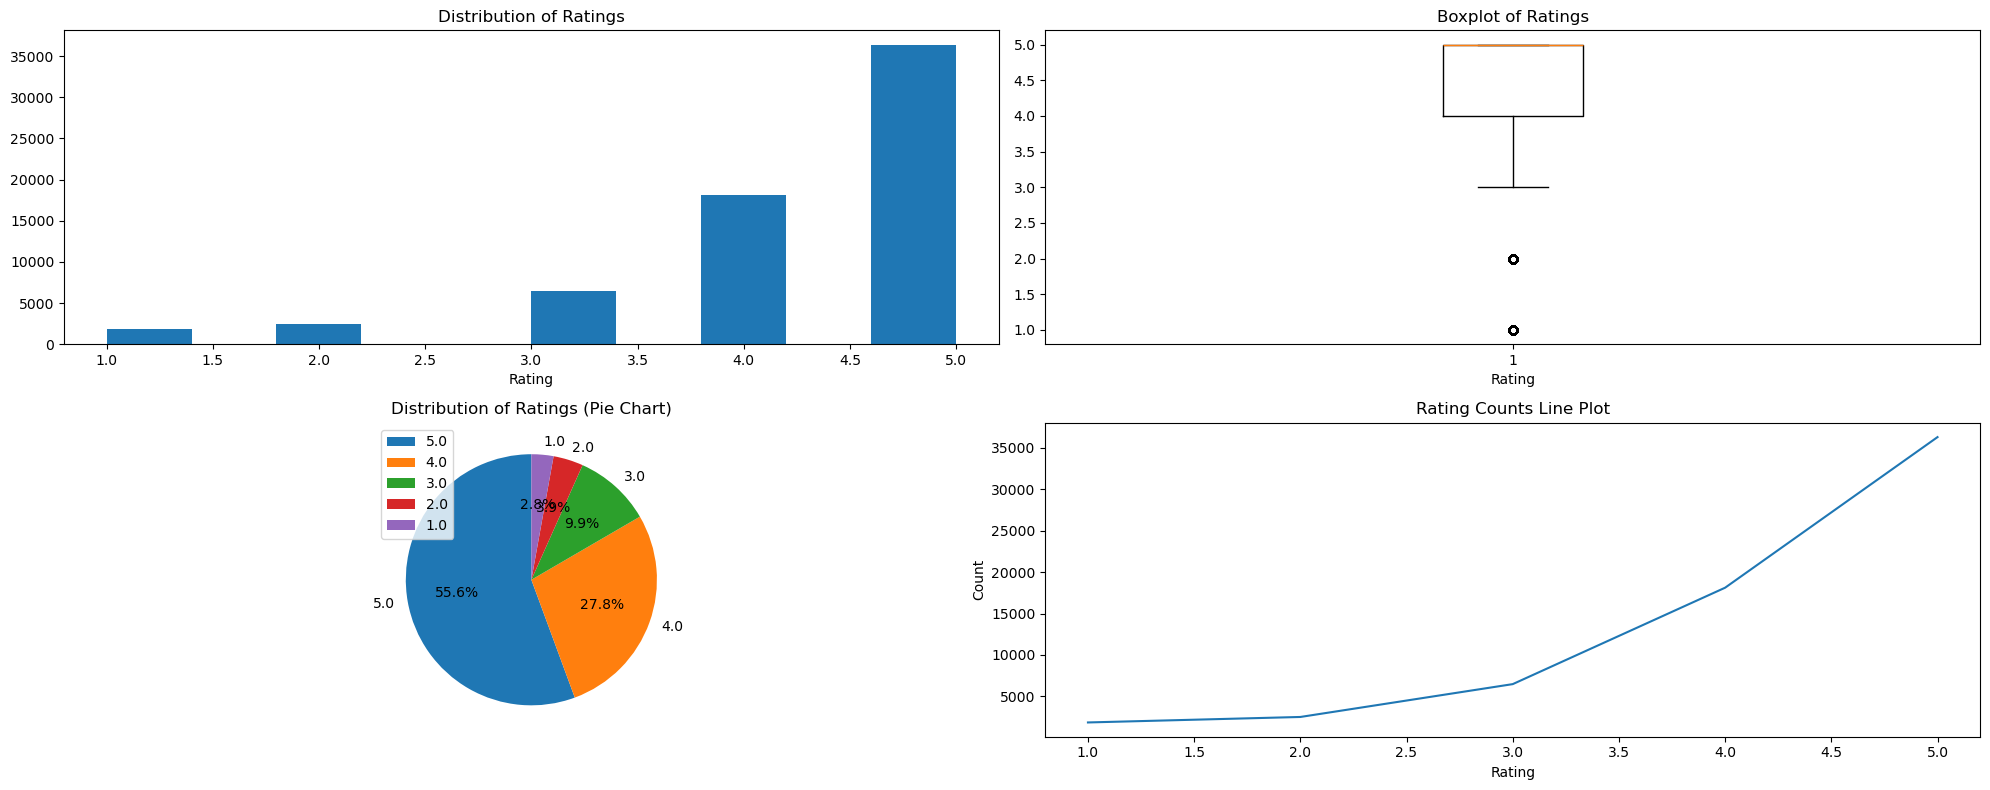

In [18]:
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(20,8))


# Histogram
ax[0,0].hist(df_final['rating'])
ax[0,0].set_xlabel('Rating')
ax[0,0].set_title("Distribution of Ratings")

#Box plot
ax[0,1].boxplot(df_final['rating'])
ax[0,1].set_xlabel('Rating')
ax[0,1].set_title("Boxplot of Ratings")

# Pie chart
rating_counts = df_final['rating'].value_counts()
ax[1,0].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
ax[1,0].legend(loc='best')
ax[1,0].set_title("Distribution of Ratings (Pie Chart)")

# Line plot
ax[1,1].plot(rating_counts.index, rating_counts.values)
ax[1,1].set_xlabel('Rating')
ax[1,1].set_ylabel('Count')
ax[1,1].set_title("Rating Counts Line Plot")



plt.tight_layout()
plt.show()


In [19]:
top_20_users = df_final['user_id'].value_counts().head(20).index
top_20_prod = df_final['prod_id'].value_counts().head(20).index
print(top_20_users)
print(top_20_prod)

Index(['ADLVFFE4VBT8', 'A3OXHLG6DIBRW8', 'A1ODOGXEYECQQ8', 'A36K2N527TXXJN',
       'A25C2M3QF9G7OQ', 'A680RUE1FDO8B', 'A1UQBFCERIP7VJ', 'A22CW0ZHY3NJH8',
       'AWPODHOB4GFWL', 'AGVWTYW0ULXHT', 'A3LGT6UZL99IW1', 'A23GFTVIETX7DS',
       'A3AYSYSLHU26U9', 'A3EXWV8FNSSFL6', 'A3A4ZAIBQWKOZS', 'A6FIAB28IS79',
       'A17BUUBOU0598B', 'A2UOHALGF2X77Q', 'A4WEZJOIZIV4U', 'AVPNQUVZWMDSX'],
      dtype='object', name='user_id')
Index(['B0088CJT4U', 'B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B00829TIEK',
       'B00829THK0', 'B008DWCRQW', 'B002R5AM7C', 'B004CLYEDC', 'B002SZEOLG',
       'B00834SJNA', 'B004T9RR6I', 'B002V88HFE', 'B0034CL2ZI', 'B00834SJSK',
       'B002WE6D44', 'B00829TIA4', 'B004CLYEFK', 'B009SYZ8OC', 'B0079UAT0A'],
      dtype='object', name='prod_id')


In [20]:
df_top_20 = df_final[df_final['user_id'].isin(top_20_users) & df_final['prod_id'].isin(top_20_prod)].pivot_table(index='user_id',columns='prod_id',values='rating');df_top_20 = df_top_20.fillna(0)

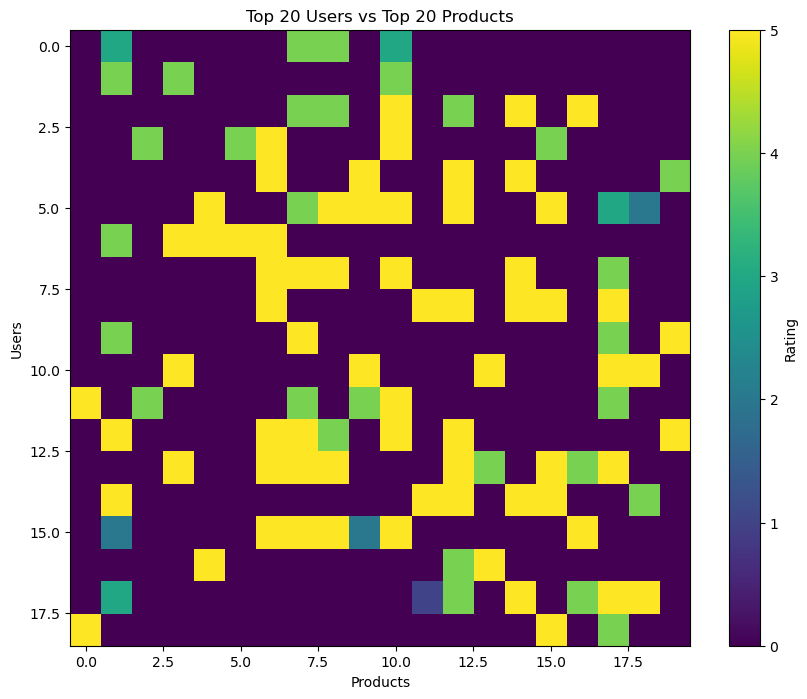

In [65]:
plt.figure(figsize=(10,8))
plt.imshow(df_top_20, aspect='auto')
plt.colorbar(label="Rating")
plt.title("Top 20 Users vs Top 20 Products")
plt.xlabel("Products")
plt.ylabel("Users")
plt.show()

In [72]:
top_products = df_final['prod_id'].value_counts().head(500).index
df_filtered = df_final[df_final['prod_id'].isin(top_products)]
user_counts = df_filtered['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index

df_filtered = df_filtered[df_filtered['user_id'].isin(active_users)]
pivot = df_filtered.pivot_table(
    index='user_id',
    columns='prod_id',
    values='rating',   # or purchase / interaction
    fill_value=0
)

In [73]:
pivot

prod_id,B00004ZCJE,B00005LEN4,B00005T3G0,B000067RT6,B00006B7DA,B00006I53S,B00006JN3G,B00006RVPW,B00007E7JU,B00007EDZG,...,B00I3YKEKG,B00IL7B2YM,B00IORDBPC,B00IVFDZBC,B00IX2VGFA,B00JC5Y6WM,B00JC5Y6YA,B00JF0D7RE,B00JP12170,B00K91DB7Y
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AZ8XSDMIX04VJ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZAC8O310IK4E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZBXKUH4AIW3X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
pivot_binary = pivot.copy()
pivot_binary[pivot_binary > 0] = 1
pivot_binary.head(50)

prod_id,B00004ZCJE,B00005LEN4,B00005T3G0,B000067RT6,B00006B7DA,B00006I53S,B00006JN3G,B00006RVPW,B00007E7JU,B00007EDZG,...,B00IL7B2YM,B00IORDBPC,B00IVFDZBC,B00IX2VGFA,B00JC5Y6WM,B00JC5Y6YA,B00JF0D7RE,B00JP12170,B00K91DB7Y,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
A10H24TDLK2VDP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
A10NMELR4KX0J6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A10O7THJ2O20AG,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A10PEXB6XAQ5XF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [139]:
item_user = pivot.T
item_user

user_id,A100UD67AHFODS,A100WO06OQR8BQ,A105S56ODHGJEK,A105TOJ6LTVMBG,A10AFVU66A79Y1,A10H24TDLK2VDP,A10NMELR4KX0J6,A10O7THJ2O20AG,A10PEXB6XAQ5XF,A10X9ME6R66JDX,...,AYO1146CBIV5C,AYOMAHLWRQHUG,AYOTEJ617O60K,AYP0YPLSP9ISM,AZ515FFZ7I2P7,AZ8XSDMIX04VJ,AZAC8O310IK4E,AZBXKUH4AIW3X,AZMY6E8B52L2T,AZNUHQSHZHSUE
prod_id,,,,,,,,,,,,,,,,,,,,,
B00004ZCJE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00005LEN4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00005T3G0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
B000067RT6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00006B7DA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B00JC5Y6YA,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00JF0D7RE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00JP12170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [140]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

item_similarity = cosine_similarity(item_user)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user.index,
    columns=item_user.index
)

In [141]:
item_similarity_df

prod_id,B00004ZCJE,B00005LEN4,B00005T3G0,B000067RT6,B00006B7DA,B00006I53S,B00006JN3G,B00006RVPW,B00007E7JU,B00007EDZG,...,B00IL7B2YM,B00IORDBPC,B00IVFDZBC,B00IX2VGFA,B00JC5Y6WM,B00JC5Y6YA,B00JF0D7RE,B00JP12170,B00K91DB7Y,cluster
prod_id,,,,,,,,,,,,,,,,,,,,,
B00004ZCJE,1.000000,0.120829,0.119194,0.00000,0.023172,0.067551,0.134039,0.055433,0.196570,0.084871,...,0.090331,0.000000,0.026678,0.041772,0.000000,0.028482,0.046827,0.051114,0.042540,0.069403
B00005LEN4,0.120829,1.000000,0.000000,0.00000,0.000000,0.000000,0.178305,0.000000,0.030375,0.383177,...,0.000000,0.000000,0.000000,0.000000,0.035371,0.000000,0.000000,0.027876,0.000000,0.081210
B00005T3G0,0.119194,0.000000,1.000000,0.00000,0.042890,0.000000,0.000000,0.036938,0.052394,0.000000,...,0.006979,0.000000,0.000000,0.039764,0.000000,0.000000,0.038052,0.000000,0.035433,0.036360
B000067RT6,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.027126,0.129010,0.020332,0.000000,...,0.000000,0.000000,0.000000,0.034720,0.023677,0.000000,0.000000,0.000000,0.000000,0.005570
B00006B7DA,0.023172,0.000000,0.042890,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.037867,0.000000,0.055700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B00JC5Y6YA,0.028482,0.000000,0.000000,0.00000,0.000000,0.062744,0.000000,0.000000,0.023370,0.000000,...,0.065663,0.000000,0.000000,0.000000,0.020411,1.000000,0.085927,0.080430,0.000000,0.138442
B00JF0D7RE,0.046827,0.000000,0.038052,0.00000,0.000000,0.090575,0.070327,0.074327,0.000000,0.000000,...,0.179046,0.125812,0.094436,0.019203,0.034102,0.085927,1.000000,0.037627,0.000000,0.109745
B00JP12170,0.051114,0.027876,0.000000,0.00000,0.037867,0.021195,0.082285,0.020872,0.046258,0.023156,...,0.069316,0.021719,0.040179,0.000000,0.000000,0.080430,0.037627,1.000000,0.118875,0.296233


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_binary)
X_scaled

array([[-0.23318561, -0.14913258, -0.15468482, ..., -0.15739414,
        -0.20489394, -0.14628458],
       [-0.23318561, -0.14913258, -0.15468482, ..., -0.15739414,
        -0.20489394,  6.83599073],
       [-0.23318561, -0.14913258, -0.15468482, ..., -0.15739414,
        -0.20489394, -0.14628458],
       ...,
       [-0.23318561, -0.14913258, -0.15468482, ..., -0.15739414,
        -0.20489394, -0.14628458],
       [-0.23318561, -0.14913258,  6.46475858, ..., -0.15739414,
        -0.20489394, -0.14628458],
       [-0.23318561, -0.14913258, -0.15468482, ..., -0.15739414,
        -0.20489394, -0.14628458]], shape=(1241, 500))

In [80]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(1241, 50)


C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

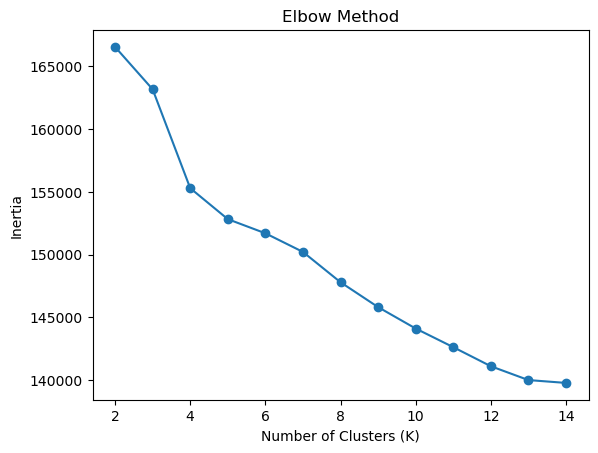

In [81]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [82]:
from sklearn.metrics import silhouette_score

for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"K={k}, Score={score}")

K=4, Score=0.14979478873261148
K=5, Score=0.15073154312416615


C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [94]:
### validating the cluster didtribution
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

pd.Series(labels).value_counts()

C:\Users\mvish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


0    769
3    390
2     42
1     40
Name: count, dtype: int64

In [111]:
pivot['cluster'] = labels

In [95]:
### visualizing the clusterings

In [96]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_pca)

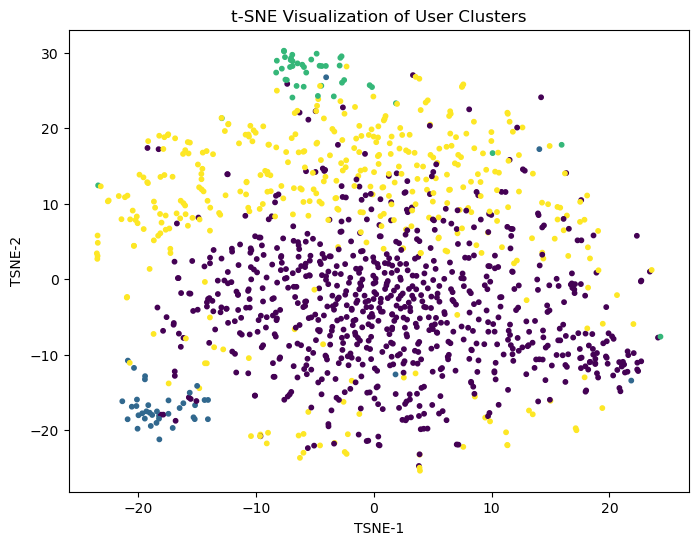

In [97]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap='viridis', s=10)

plt.title("t-SNE Visualization of User Clusters")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.show()

In [98]:
X = X_pca

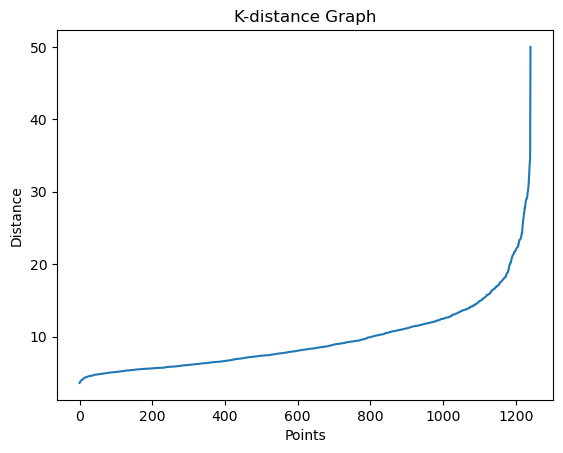

In [100]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [105]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.002, min_samples=5)
db_labels = dbscan.fit_predict(X)

In [106]:
pd.Series(db_labels).value_counts()

-1    1241
Name: count, dtype: int64

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(pivot.drop(columns='cluster'))

In [114]:
## fuction for user similarity
def recommend(user_id, top_n=10):
    user_idx = pivot.index.get_loc(user_id)
    user_cluster = pivot.loc[user_id, 'cluster']
    
    # users in same cluster
    cluster_users = pivot[pivot['cluster'] == user_cluster]
    
    cluster_indices = [pivot.index.get_loc(u) for u in cluster_users.index]
    
    # similarity scores
    sim_scores = similarity[user_idx][cluster_indices]
    
    # top similar users
    top_users_idx = np.argsort(sim_scores)[-10:]
    top_users = cluster_users.iloc[top_users_idx]
    
    # aggregate
    recommendations = top_users.drop(columns='cluster').mean()
    
    # remove already interacted
    user_data = pivot.loc[user_id].drop('cluster')
    recommendations = recommendations[user_data == 0]
    
    return recommendations.sort_values(ascending=False).head(top_n)

In [123]:
recommend("A11LNPG39A2ZV4")

prod_id
B0019EHU8G    1.0
B0088CJT4U    1.0
B000HDJT4S    0.9
B0079UAT0A    0.9
B000NP3DJW    0.9
B0041Q38NU    0.9
B00825BZUY    0.8
B002SQK2F2    0.6
B001FA1O18    0.5
B006EKIQYM    0.5
dtype: float64

In [142]:
## function for product similarity
def recommend_similar_products(prod_id, top_n=10):

    # similarity scores for given product
    sim_scores = item_similarity_df[prod_id]

    # sort similar products
    sim_scores = sim_scores.sort_values(ascending=False)

    # remove itself
    sim_scores = sim_scores.drop(prod_id)

    return sim_scores.head(top_n)

In [143]:
recommend_similar_products('B00JC5Y6WM')

prod_id
B00G6CLNCK    0.297745
B00IVFDZBC    0.286769
cluster       0.261253
B00DT04I9W    0.258532
B00F9ZQQ8Q    0.257921
B00G6CLN3Y    0.214779
B006WVR9GY    0.192114
B00829THK0    0.159357
B005GOINEK    0.157905
B00834SJNA    0.156954
Name: B00JC5Y6WM, dtype: float64

In [146]:
def hybrid_recommend(user_id=None, prod_id=None):

    result = {}

    # 1. user-based signal
    if user_id is not None:
        user_recs = recommend(user_id)
        for p, s in user_recs.items():
            result[p] = result.get(p, 0) + 0.7 * s

    # 2. item-based signal
    if prod_id is not None:
        item_recs = recommend_similar_products(prod_id)
        for p, s in item_recs.items():
            result[p] = result.get(p, 0) + 0.3 * s

    # 3. return ranked products
    return sorted(result.items(), key=lambda x: x[1], reverse=True)[:10]

In [148]:
hybrid_recommend("A100UD67AHFODS","B009SYZ8OC")

[('B003ES5ZUU', 1.0279029565856779),
 ('B004G6002M', 0.9799999999999999),
 ('B003LSTD38', 0.7),
 ('B001MSU1FS', 0.63),
 ('B002J9HBIO', 0.5599999999999999),
 ('B002WE6D44', 0.48999999999999994),
 ('B005HMKKH4', 0.42),
 ('B0034XRDUA', 0.35),
 ('B0027VT6V4', 0.35),
 ('B000TKHBDK', 0.35)]